## 1. import library dan load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# HS_Code dibaca sebagai teks agar angka 0 di depan kode tidak hilang
df = pd.read_csv('HS_Code.csv', dtype={'HS Code': str})
df.head()

,HS Code,Description
0,01012900,"live horses, other than pure-bred breeding ani..."
1,01013010,"live asses, pure-bred breeding animals"
2,01013090,"live asses, other than pure-bred breeding animals"
3,01019000,live mules and hinnies
4,01022100,"live cattle, pure-bred breeding animals"


## 2. struktur dasar data

In [2]:
# ukuran data dan tipe kolom
print('jumlah baris dan kolom:', df.shape)
print()
df.info()

jumlah baris dan kolom: (11554, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11554 entries, 0 to 11553
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   HS Code      11554 non-null  object
 1   Description  11554 non-null  object
dtypes: object(2)
memory usage: 180.7+ KB


In [3]:
# pemeriksaan missing value dan baris duplikat
print('missing value per kolom:')
print(df.isnull().sum())
print()
print('jumlah baris duplikat:', df.duplicated().sum())

missing value per kolom:
HS Code        0
Description    0
dtype: int64

jumlah baris duplikat: 0


## 3. pemeriksaan format kode hs

In [4]:
# cek konsistensi panjang digit kode hs
df['panjang_kode'] = df['HS Code'].str.len()
print('distribusi panjang digit kode:')
print(df['panjang_kode'].value_counts())

distribusi panjang digit kode:
panjang_kode
8    11554
Name: count, dtype: int64


## 4. distribusi bab (2 digit pertama)

In [5]:
# dua digit pertama kode hs menunjukkan bab atau kategori utama barang
df['bab'] = df['HS Code'].str[:2]
print('jumlah bab unik:', df['bab'].nunique())
print()
print('10 bab dengan jumlah kode terbanyak:')
print(df['bab'].value_counts().head(10))

jumlah bab unik: 98

10 bab dengan jumlah kode terbanyak:
bab
84    1316
87    1066
85     896
29     484
03     395
39     385
72     377
73     277
48     253
90     241
Name: count, dtype: int64


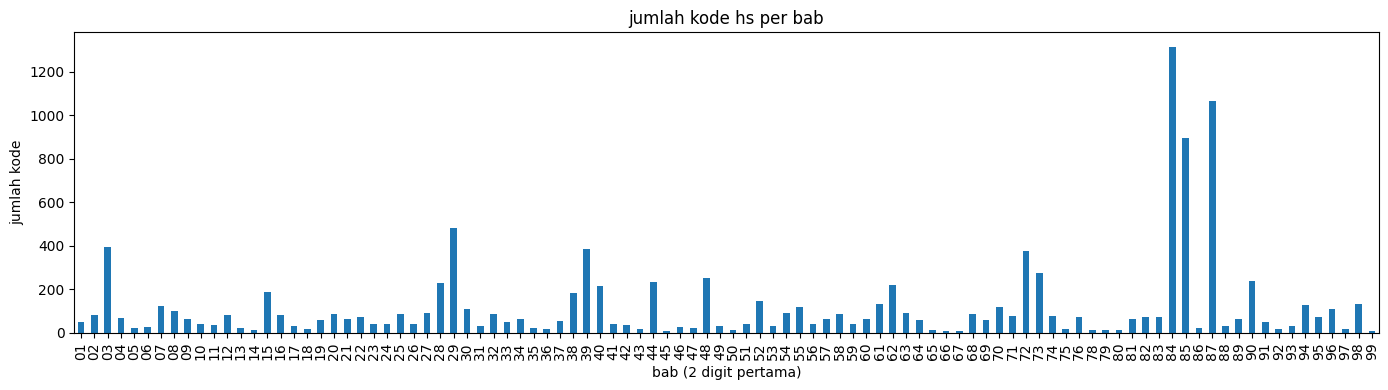

In [6]:
# visualisasi sebaran jumlah kode di tiap bab
plt.figure(figsize=(14, 4))
df['bab'].value_counts().sort_index().plot(kind='bar')
plt.title('jumlah kode hs per bab')
plt.xlabel('bab (2 digit pertama)')
plt.ylabel('jumlah kode')
plt.tight_layout()
plt.show()

## 5. analisis panjang deskripsi

In [7]:
# hitung panjang deskripsi dalam jumlah kata dan karakter
df['jumlah_kata'] = df['Description'].str.split().str.len()
df['jumlah_karakter'] = df['Description'].str.len()
print('statistik jumlah kata per deskripsi:')
print(df['jumlah_kata'].describe())

statistik jumlah kata per deskripsi:
count    11554.000000
mean        14.825688
std          8.551720
min          1.000000
25%          8.000000
50%         14.000000
75%         21.000000
max         80.000000
Name: jumlah_kata, dtype: float64


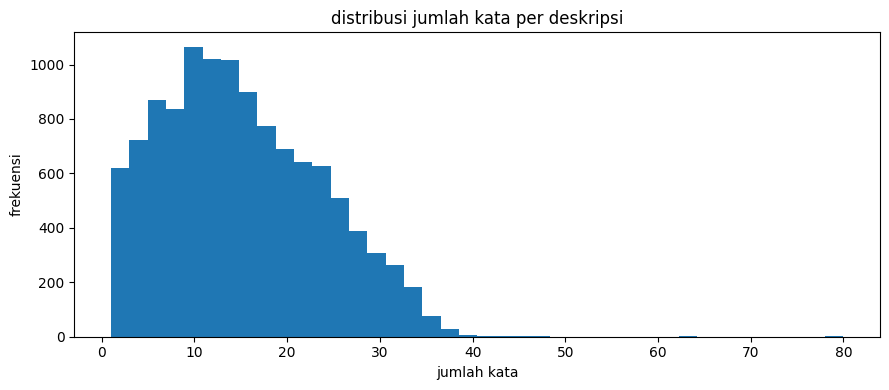

In [8]:
# distribusi panjang deskripsi (jumlah kata)
plt.figure(figsize=(9, 4))
df['jumlah_kata'].plot(kind='hist', bins=40)
plt.title('distribusi jumlah kata per deskripsi')
plt.xlabel('jumlah kata')
plt.ylabel('frekuensi')
plt.tight_layout()
plt.show()

## 6. pemeriksaan duplikat deskripsi dan bahasa

In [9]:
# satu uraian barang yang sama dapat melekat pada beberapa sub-kode
print('jumlah deskripsi yang berulang:', df['Description'].duplicated().sum())
print()
# contoh deskripsi yang muncul lebih dari satu kali
print('contoh deskripsi yang paling sering berulang:')
print(df['Description'].value_counts().head(5))

jumlah deskripsi yang berulang: 66

contoh deskripsi yang paling sering berulang:
Description
matching transformers parts and accessories of machines for sawing monocrystal semiconductor boules\ninto slices, or wafers into chips                                                    5
of a kind used for the goods of heading 8415, 8418, 8450, 8509 or 8516 parts and accessories of machines for sawing monocrystal semiconductor boules into slices, or wafers into chips    4
other plates, sheets, film, foil and strip, of plastics, cellular, of polymers of styrene :rigid : of condensation\nor rearrangement polymerisation products, plates and sheets           2
fungicides, other than in aerosol containers                                                                                                                                              2
herbicides, in aerosol containers                                                                                                                         

In [10]:
# pemeriksaan bahasa lewat kata yang paling sering muncul
semua_kata = ' '.join(df['Description']).lower().split()
print('total kata:', len(semua_kata))
print('kata unik (ukuran kosakata):', len(set(semua_kata)))
print()
print('15 kata paling sering muncul:')
for kata, jumlah in Counter(semua_kata).most_common(15):
    print(kata, jumlah)

total kata: 171296
kata unik (ukuran kosakata): 13851

15 kata paling sering muncul:
of 10740
or 6825
other 4770
and 4651
than 4218
for 3927
not 3413
a 2493
in 2227
with 2070
the 1429
= 1130
by 1100
exceeding 1089
heading 963


In [11]:
# cek deskripsi yang panjang
panjang = df['Description'].str.split().str.len()
print('deskripsi > 50 kata :', (panjang > 50).sum())
print('deskripsi > 100 kata:', (panjang > 100).sum())
print()
# 5 deskripsi terpanjang
for idx in panjang.sort_values(ascending=False).head(5).index:
    print(df.loc[idx, 'HS Code'], '|', int(panjang[idx]), 'kata')
    print(df.loc[idx, 'Description'][:250], '...')
    print()

deskripsi > 50 kata : 2
deskripsi > 100 kata: 0

84669330 | 80 kata
parts for machines of subheading 84561110, 84561210, 84562000, or 84563000, of a kind used solely or principally for the manufacture of printed circuits, printed circuit assemblies, parts of machines of heading 8517, or parts of automatic data proces ...

05059090 | 63 kata
skins and other parts of birds, powder and waste feathers and parts of feathers or parts of feathers, feathers and parts of faethers not elsewhere classified in 0505 skins&other parts of birds, with their feathers and parts of feathers (w.o.n with tr ...

84798950 | 47 kata
machines for assembling cpu daughter boards in plastic cases or housings; apparatus for the regeneration of chemical solutions used in the manufacture of pcb; equipment for mechanically cleaning the surfaces of pcb during manufacturing; registration  ...

85234914 | 45 kata
disc for laser reading systems for reproducing representations of instructions, data, sound and image, reco

## 7. ringkasan temuan

- dataset berisi 11.554 kode hs dengan dua kolom (HS_Code dan Description), tanpa missing value dan tanpa baris duplikat.
- semua kode berformat 8 digit dan mencakup 98 bab.
- deskripsi barang mayoritas pendek (median sekitar 14 kata) dan ditulis dalam bahasa inggris.
- ada 66 deskripsi yang sama persis di kode berbeda. ini dipertahankan.
- karena tiap kode cuma punya satu deskripsi dan tidak ada data berlabel, pendekatan yang dipilih adalah pencarian berdasarkan kemiripan makna (semantic search), bukan klasifikasi.